In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [24]:
df = pd.read_csv('/content/creditcard (1).csv')

In [25]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [26]:
df.shape

(284807, 31)

In [27]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [28]:
# Column names
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [29]:
# Fraud vs Non-Fraud
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [30]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

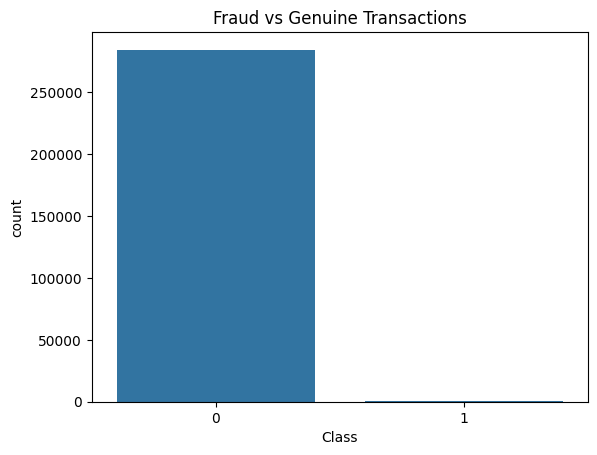

In [32]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [33]:
fraud_percentage = (df['Class'].value_counts()[1] / len(df)) * 100

print("Fraud Percentage:", fraud_percentage)

Fraud Percentage: 0.1727485630620034


In [34]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

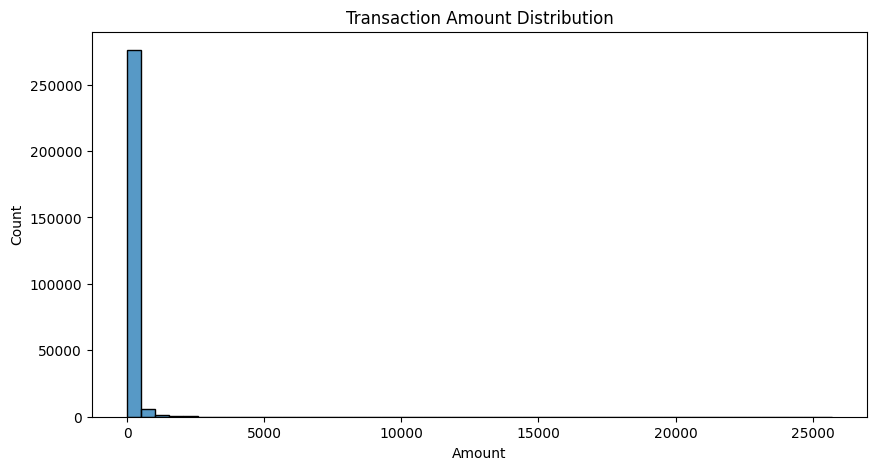

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Transaction Amount Distribution")
plt.show()

In [36]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud Amount Mean:", fraud['Amount'].mean())
print("Normal Amount Mean:", normal['Amount'].mean())

Fraud Amount Mean: 122.21132113821139
Normal Amount Mean: 88.29102242231328


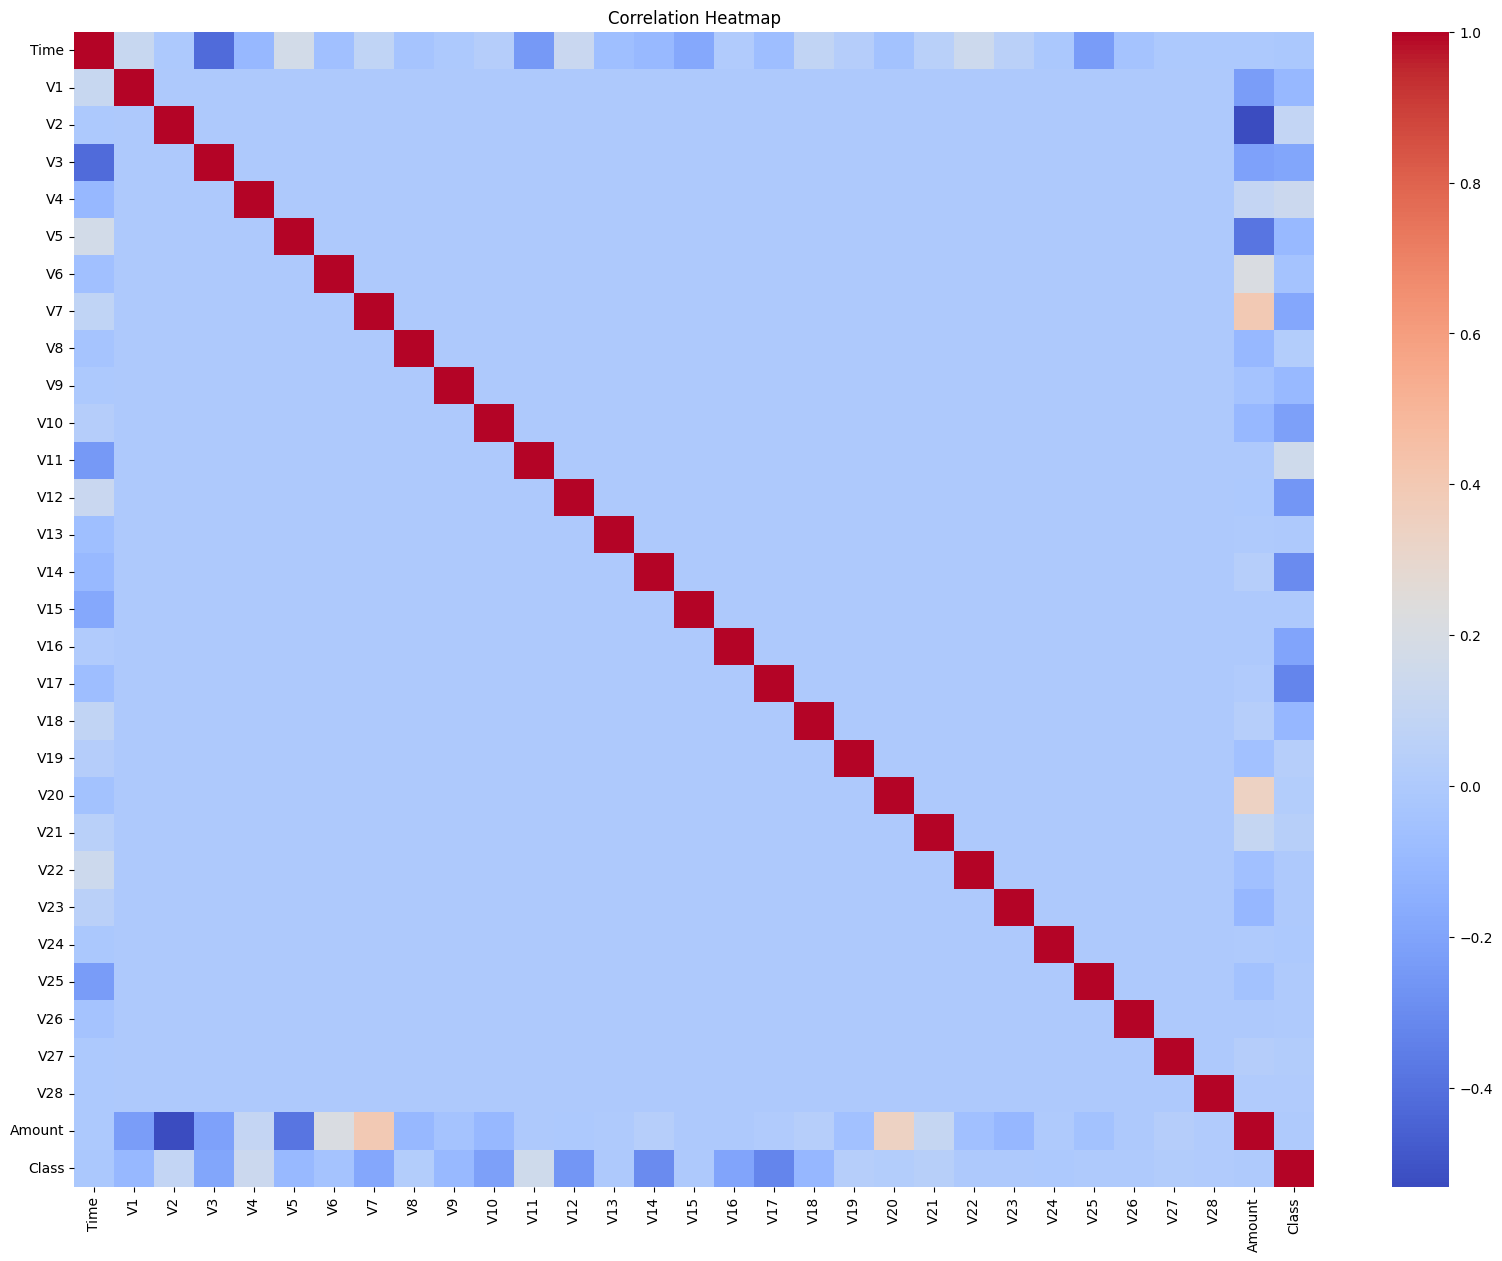

In [37]:
plt.figure(figsize=(20,15))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

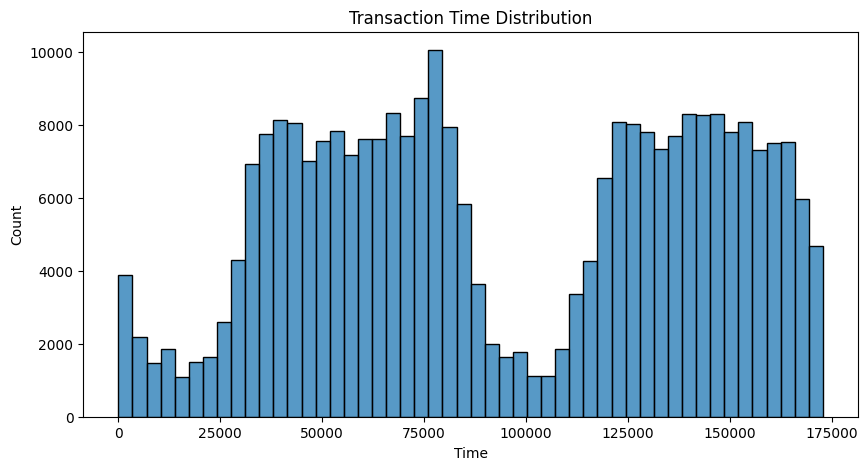

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

In [39]:
#PHASE 3 — Data Preprocessing

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [41]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [42]:
X = df.drop('Class', axis=1)
y = df['Class']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
scaler.fit_transform(X_train)

array([[ 1.41158751,  0.99337908, -0.45603659, ...,  0.19191152,
        -0.09910576, -0.32249376],
       [ 0.62314085,  1.03850725, -0.02934912, ...,  0.00639701,
        -0.21152423, -0.33976388],
       [-1.13068022, -0.50676613,  0.36606499, ...,  0.09413695,
         0.56642647,  0.34669349],
       ...,
       [-1.25471074,  0.54569899,  0.04401572, ...,  0.07676455,
         0.07564817, -0.17053266],
       [-1.48398822,  0.65325241,  0.18256566, ..., -0.14759091,
        -0.0184768 , -0.34813969],
       [-1.39061787, -0.30573748,  0.47027277, ...,  0.93509494,
         0.63073809, -0.32380996]])

In [46]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [47]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [48]:
X_train_resampled
y_train_resampled

,Class
0,0
1,0
2,0
3,0
4,0
...,...
454897,1
454898,1
454899,1
454900,1


In [49]:
X_test_scaled
y_test

,Class
263020,0
11378,0
147283,0
219439,0
36939,0
...,...
54199,0
184616,0
274532,0
269819,0


In [50]:
# Check class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


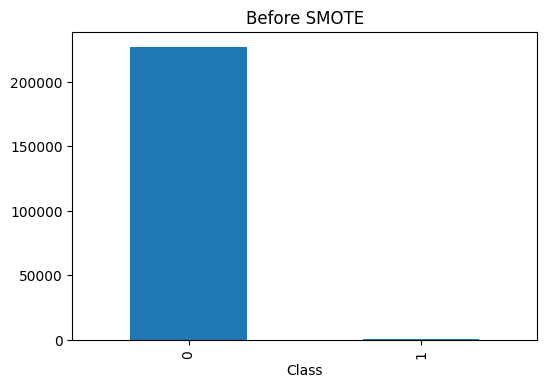

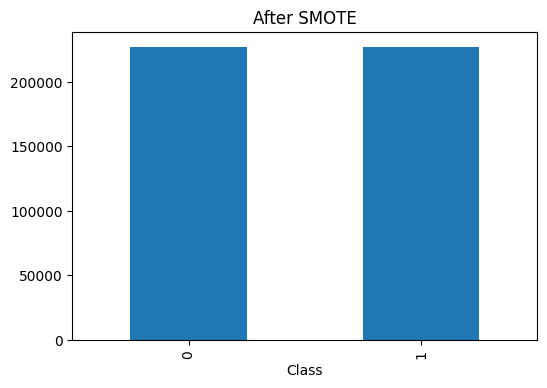

In [51]:
plt.figure(figsize=(6,4))

y_train.value_counts().plot(
    kind='bar'
)

plt.title("Before SMOTE")
plt.show()


plt.figure(figsize=(6,4))

y_train_resampled.value_counts().plot(
    kind='bar'
)

plt.title("After SMOTE")
plt.show()

In [52]:
#PHASE 4 — Model Building

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [54]:
#Train Logistic Regression
lr = LogisticRegression()

lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9972262209894316
[[56803    61]
 [   97     1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.02      0.01      0.01        98

    accuracy                           1.00     56962
   macro avg       0.51      0.50      0.51     56962
weighted avg       1.00      1.00      1.00     56962



In [56]:
#Train Decision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt.predict(X_test_scaled)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.997559776693234
[[56746   118]
 [   21    77]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.79      0.53        98

    accuracy                           1.00     56962
   macro avg       0.70      0.89      0.76     56962
weighted avg       1.00      1.00      1.00     56962



In [59]:
#Train Random Forest

In [60]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test_scaled)

In [61]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9994908886626171
[[56852    12]
 [   17    81]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [62]:
#Train XGBoost

In [63]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_test_scaled)

In [64]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(confusion_matrix(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9991924440855307
[[56833    31]
 [   15    83]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.85      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [65]:
#Calculate Metrics for All Models

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [67]:
results = pd.DataFrame(columns=[
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
])

models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

for name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.loc[len(results)] = [
        name,
        accuracy,
        precision,
        recall,
        f1
    ]

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.997226,0.016129,0.010204,0.012500
1,Decision Tree,0.997560,0.394872,0.785714,0.525597
2,Random Forest,0.999491,0.870968,0.826531,0.848168
3,XGBoost,0.999192,0.728070,0.846939,0.783019


In [68]:
#Sort by Recall
results.sort_values(
    by='Recall',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.999192,0.728070,0.846939,0.783019
2,Random Forest,0.999491,0.870968,0.826531,0.848168
1,Decision Tree,0.997560,0.394872,0.785714,0.525597
0,Logistic Regression,0.997226,0.016129,0.010204,0.012500


In [69]:
#Sort by F1 Score
results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.999491,0.870968,0.826531,0.848168
3,XGBoost,0.999192,0.728070,0.846939,0.783019
1,Decision Tree,0.997560,0.394872,0.785714,0.525597
0,Logistic Regression,0.997226,0.016129,0.010204,0.012500


In [70]:
#ROC AUC Comparison
from sklearn.metrics import roc_auc_score
roc_results = pd.DataFrame(columns=[
    'Model',
    'ROC AUC'
])

roc_results.loc[len(roc_results)] = [
    'Logistic Regression',
    roc_auc_score(y_test, y_pred_lr)
]

roc_results.loc[len(roc_results)] = [
    'Decision Tree',
    roc_auc_score(y_test, y_pred_dt)
]

roc_results.loc[len(roc_results)] = [
    'Random Forest',
    roc_auc_score(y_test, y_pred_rf)
]

roc_results.loc[len(roc_results)] = [
    'XGBoost',
    roc_auc_score(y_test, y_pred_xgb)
]

roc_results

,Model,ROC AUC
0,Logistic Regression,0.504566
1,Decision Tree,0.891820
2,Random Forest,0.913160
3,XGBoost,0.923197


In [ ]:
#F1 Score Comparison

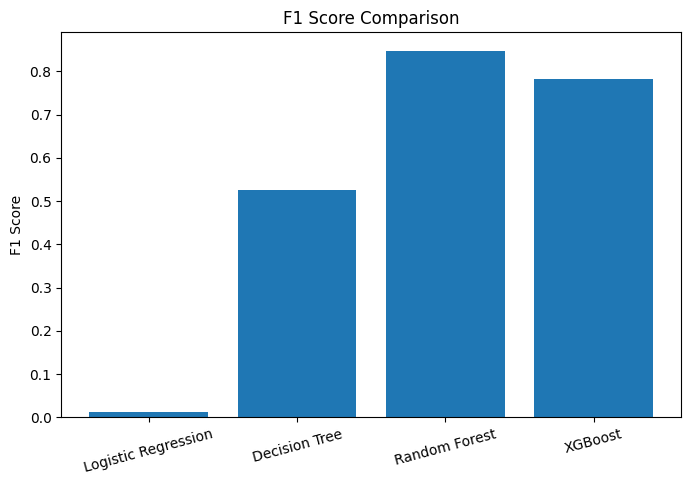

In [71]:
plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['F1 Score']
)

plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')

plt.xticks(rotation=15)

plt.show()

In [ ]:
#Random forest is the best modal

In [72]:
#Feature Importance (For Random Forest)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.191127
10,V10,0.111454
4,V4,0.111395
12,V12,0.095690
17,V17,0.082761
3,V3,0.063935
11,V11,0.049290
16,V16,0.045124
2,V2,0.038541
9,V9,0.026552


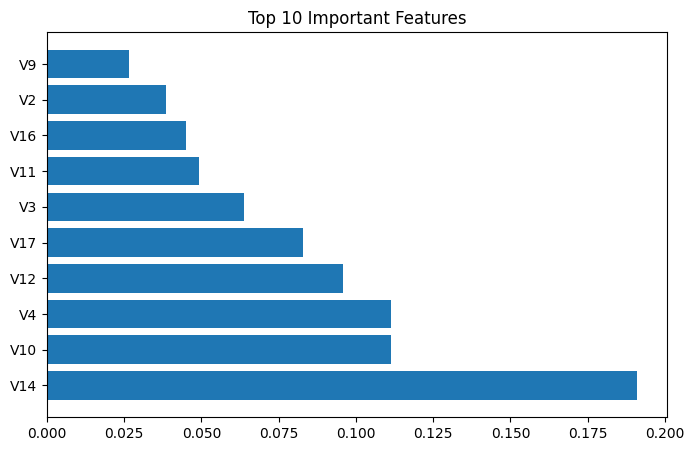

In [73]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Important Features')

plt.show()

In [ ]:
# Among the four machine learning models tested,
# Random Forest achieved the highest Recall and F1 Score,
# making it the most effective model for detecting fraudulent
# credit card transactions.

# SMOTE was applied to address class imbalance,
# significantly improving the model's ability to identify fraud cases

In [76]:
import joblib

joblib.dump(rf, 'best_fraud_model.pkl')

from google.colab import files

files.download('best_fraud_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>